In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Data gathering from final states

In [20]:
# Running the eval_env only on final .pkl files - check the evalTarg.sh is running the correct number of runs

#./scripts/evalTarg.sh c[a]rl run_name pklNameInFolder eval_env
#!bash ./scripts/evalTarg.sh "crl" "splitCRL" "final_9015296.pkl" "ant_custom_masses"
#!bash ./scripts/evalTarg.sh "carl" "splitGCARL0.05" "final_9015296.pkl" "ant_custom_masses"
#!bash ./scripts/evalTarg.sh "carl" "splitGCARL0.10" "final_9015296.pkl" "ant_custom_masses"
#!bash ./scripts/evalTarg.sh "carl" "splitGCARL0.20" "final_9015296.pkl" "ant_custom_masses"


In [27]:
run_names = ["splitCRL", "splitGCARL0.05", "splitGCARL0.10", "splitGCARL0.20"]
target = 'eval/' + 'episode_success'
target = 'eval/' + 'episode_success_any'
target = 'eval/' + 'episode_success_easy'


dbs = {}
for name in run_names:
    dbs[name] = pd.read_csv(name + "_evalData.txt", index_col='seed')

vals = {}
for name in run_names:
    vals[name] = dbs[name][target]

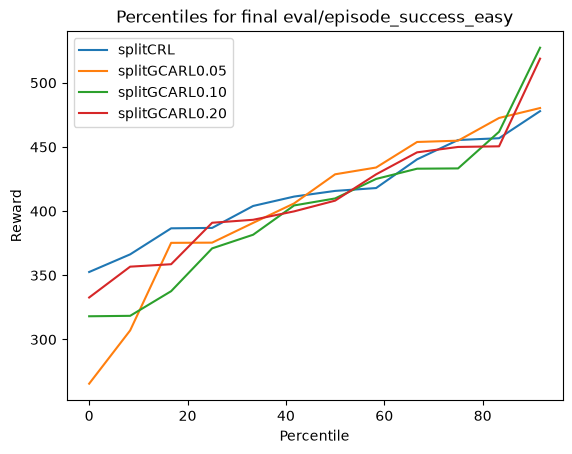

In [28]:

end_data = {}
for name in run_names:
    enddata = vals[name].sort_values()
    end_data[name] = enddata
    
    plt.plot(np.arange(len(enddata))* 100/len(enddata), enddata, label=name)
             
plt.xlabel("Percentile")
plt.ylabel("Reward")
plt.title("Percentiles for final " + target)
plt.legend()